### Exploratory Data Analysis

In [1]:
#importing the necessary libraries:

import pandas as pd
import numpy as np
from IPython.core.pylabtools import figsize
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.pyplot import figure

In [2]:
import re

def smart_parse_dates(s):

    s = s.astype(str)
    out = pd.Series(pd.NaT, index=s.index)
    patterns = [
        (r'^\d{4}-\d{2}-\d{2}$',        '%Y-%m-%d'),
        (r'^\d{2}/\d{2}/\d{4}$',        '%m/%d/%Y'),
        (r'^\d{2}-\d{2}-\d{4}$',        '%d-%m-%Y'),
        (r'^\d{2} [A-Za-z]{3} \d{4}$',  '%d %b %Y'),
        (r'^\d{4}/\d{2}/\d{2}$',        '%Y/%m/%d'),
    ]
    for pat, fmt in patterns:
        mask = s.str.match(pat, na=False)
        out.loc[mask] = pd.to_datetime(s[mask], format=fmt, errors='coerce')
    return out

**1. How does transaction volume change over time across 1997–1998, and are there clear monthly or seasonal demand patterns?**

In [3]:
#importing the necessary cleaned tables from the dataset:
tr97 = pd.read_csv(r"C:\Users\Ranu Gupta\OneDrive\Desktop\Project 1- Sales Analytics'\cleaned dataset\cleaned Transaction-1997.csv")
tr98 = pd.read_csv(r"C:\Users\Ranu Gupta\OneDrive\Desktop\Project 1- Sales Analytics'\cleaned dataset\cleaned Transactions-1998.csv")

In [4]:
tr97.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86837 entries, 0 to 86836
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_date  86422 non-null  object 
 1   stock_date        85942 non-null  object 
 2   product_id        86837 non-null  int64  
 3   customer_id       82447 non-null  float64
 4   store_id          86837 non-null  int64  
 5   quantity          85063 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 4.0+ MB


In [5]:
tr98.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182883 entries, 0 to 182882
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_date  181971 non-null  object 
 1   stock_date        181043 non-null  object 
 2   product_id        182883 non-null  int64  
 3   customer_id       173786 non-null  float64
 4   store_id          182883 non-null  int64  
 5   quantity          179296 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 8.4+ MB


In [6]:
# correcting the data types of the values:
for df in [tr97, tr98]:
    df["transaction_date"] = smart_parse_dates(df["transaction_date"])
    df["stock_date"] = smart_parse_dates(df["stock_date"])
    df["product_id"] = df["product_id"].astype(str)
    df["customer_id"] = df["customer_id"].astype("Int64").astype("string")
    df["store_id"] = df["store_id"].astype(str)

# customer_id was first converted into int then to string because contains the missing values, unlike the store_id and product_id, so that pandas do not convert the nan values to "nan".

In [7]:
for col in [tr97,tr98]:
    print(col.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86837 entries, 0 to 86836
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_date  86422 non-null  datetime64[ns]
 1   stock_date        85942 non-null  datetime64[ns]
 2   product_id        86837 non-null  object        
 3   customer_id       82447 non-null  string        
 4   store_id          86837 non-null  object        
 5   quantity          85063 non-null  float64       
dtypes: datetime64[ns](2), float64(1), object(2), string(1)
memory usage: 4.0+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182883 entries, 0 to 182882
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_date  181971 non-null  datetime64[ns]
 1   stock_date        181043 non-null  datetime64[ns]
 2   product_id        182883 non-null  obj

In [8]:
# Combining both the transaction tables and then grouping them by year and month:
tr_all  = pd.concat([tr97,tr98], ignore_index= True)
tr_all["month"] = tr_all["transaction_date"].dt.month
tr_all["year"] = tr_all["transaction_date"].dt.year

monthly_by_year = tr_all.groupby(["year", "month"]).size().reset_index(name = "transactions")

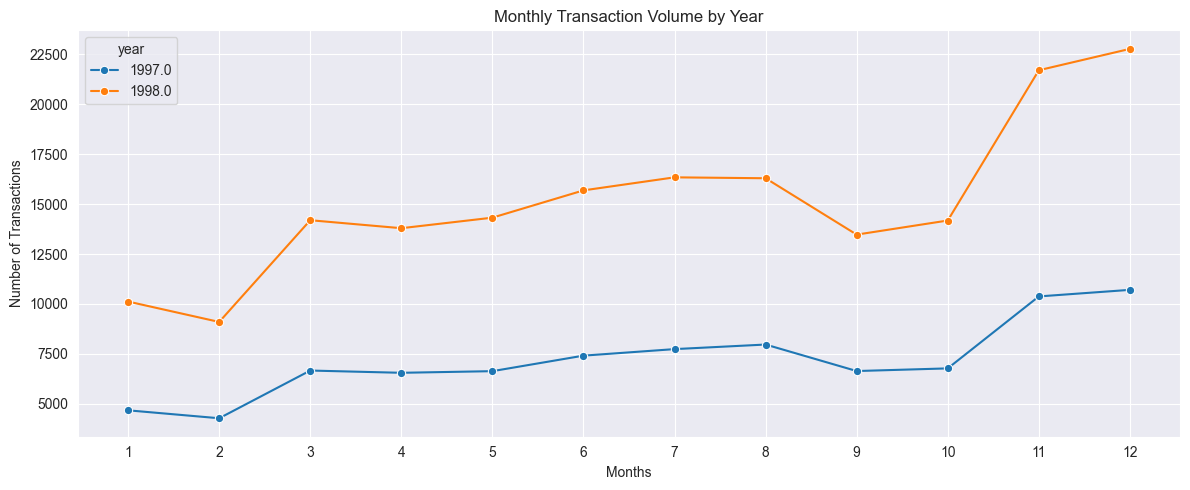

In [150]:
plt.figure(figsize= (12,5))
sns.lineplot(data = monthly_by_year, x = "month", y = "transactions", hue = "year", marker = "o", palette= "tab10")
plt.title("Monthly Transaction Volume by Year")
plt.xlabel("Months")
plt.ylabel("Number of Transactions")
plt.xticks(range(1,13))
plt.tight_layout()
plt.savefig("Monthly Transaction Volume by Year")


Overall, transaction volume follows a broadly similar monthly pattern across 1997 and 1998. Transactions decline in **February**, increase sharply in **March**, and generally **rise through the summer months** before **falling in September**. Volumes then recover in October and **increase sharply in November**, with December recording a further increase. **November and December** represent the strongest transaction periods, while **February** consistently records one of the lowest volumes. <br>
<br>
The repeated monthly pattern across both years suggests some seasonality in transaction activity, although a longer time period would be needed to establish a strong seasonal trend.


**2.) Which product brands contribute the most to sales quantity, and how concentrated is overall demand among the top performers?**

In [10]:
# before plotting graphs we will identify the outliners and remove them if necessary
tr_all.describe().round(2)

,transaction_date,stock_date,quantity,month,year
count,268393,266985,264359.00,268393.00,268393.00
mean,1998-03-27 11:07:54.034717696,1998-03-22 02:09:48.086971264,2.79,7.22,1997.68
min,1997-01-01 00:00:00,1996-12-22 00:00:00,-3.00,1.00,1997.00
25%,1997-11-06 00:00:00,1997-10-31 00:00:00,2.00,4.00,1997.00
50%,1998-05-01 00:00:00,1998-04-26 00:00:00,2.00,7.00,1998.00
75%,1998-09-12 00:00:00,1998-09-06 00:00:00,3.00,10.00,1998.00
max,1998-12-31 00:00:00,1999-01-05 00:00:00,98.00,12.00,1998.00
std,NaN,NaN,2.90,3.41,0.47


In [11]:
tr_all.shape

(269720, 8)

In [12]:
tr_all[tr_all["quantity"] < 0].shape

(983, 8)

In [13]:
tr_all.loc[tr_all["quantity"] < 0, "quantity"].value_counts()

quantity
-2.0    343
-1.0    323
-3.0    317
Name: count, dtype: int64

In [14]:
# created a new dataframe that keeps only transactions with a known, non-negative quantity (drops negative-quantity errors and missing-quantity rows)
tr_clean = tr_all[tr_all["quantity"] >= 0].copy()

In [15]:
tr_clean.describe().round(2)

,transaction_date,stock_date,quantity,month,year
count,262080,260700,263376.00,262080.00,262080.00
mean,1998-03-27 13:09:20.109890304,1998-03-22 04:22:01.353279744,2.81,7.22,1997.68
min,1997-01-01 00:00:00,1996-12-22 00:00:00,0.00,1.00,1997.00
25%,1997-11-06 00:00:00,1997-10-31 00:00:00,2.00,4.00,1997.00
50%,1998-05-02 00:00:00,1998-04-26 00:00:00,2.00,7.00,1998.00
75%,1998-09-12 00:00:00,1998-09-06 00:00:00,3.00,10.00,1998.00
max,1998-12-31 00:00:00,1999-01-05 00:00:00,98.00,12.00,1998.00
std,NaN,NaN,2.89,3.41,0.47


In [16]:
tr_clean["quantity"].value_counts().sort_index()

quantity
0.0       309
1.0     52471
2.0     84181
3.0     67528
4.0     35860
5.0     14273
6.0      4691
7.0      1293
8.0       308
9.0       108
10.0      164
11.0       56
12.0      147
13.0       49
14.0      136
15.0       69
16.0       85
18.0      159
20.0      126
21.0       61
22.0       77
24.0      193
25.0       10
26.0       81
27.0       70
28.0      118
30.0       85
32.0       28
33.0       66
35.0       11
36.0      103
39.0       72
40.0       58
42.0       58
44.0       36
45.0       17
48.0       43
49.0        1
50.0       14
52.0       32
54.0        3
55.0       15
56.0       32
60.0       19
64.0        1
65.0       13
66.0        3
70.0       21
72.0        6
77.0        1
78.0        5
84.0        8
96.0        1
98.0        1
Name: count, dtype: int64

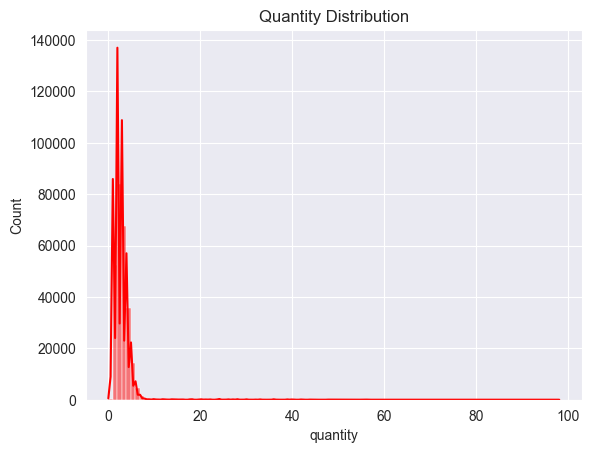

In [137]:
# checking the distribution of quantity
plt.figure()
sns.histplot(data = tr_clean, x= "quantity", bins = 100, color = "red", kde = True)
plt.title("Quantity Distribution")
plt.savefig("Quantity Distribution")

In [18]:
tr_clean["quantity"].skew()

np.float64(11.341388151366836)

The quantity distribution is highly right-skewed (skewness = 11.34) , with most transactions involving 1–5 units. Although a small number of transactions have higher quantities, these values occur across a range of recurring quantities and appear to represent legitimate bulk purchases. Therefore, no positive quantity outliers were removed.

In [19]:
pro = pd.read_csv(r"C:\Users\Ranu Gupta\OneDrive\Desktop\Project 1- Sales Analytics'\cleaned dataset\cleaned_products.csv")

In [20]:
pro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_id            1560 non-null   int64  
 1   product_brand         1560 non-null   object 
 2   product_name          1560 non-null   object 
 3   product_sku           1560 non-null   object 
 4   product_retail_price  1560 non-null   float64
 5   product_cost          1560 non-null   float64
 6   product_weight        1560 non-null   float64
 7   recyclable            1560 non-null   object 
 8   low_fat               1560 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 109.8+ KB


In [21]:
pro["product_id"] = pro["product_id"].astype(str)

In [22]:
merge_pro_tr = pd.merge(pro, tr_clean, on = "product_id")

In [23]:
print(tr_clean.shape,merge_pro_tr.shape)

(263376, 8) (262996, 16)


In [24]:
brand_qty = merge_pro_tr.groupby("product_brand")["quantity"].sum().sort_values(ascending= False)

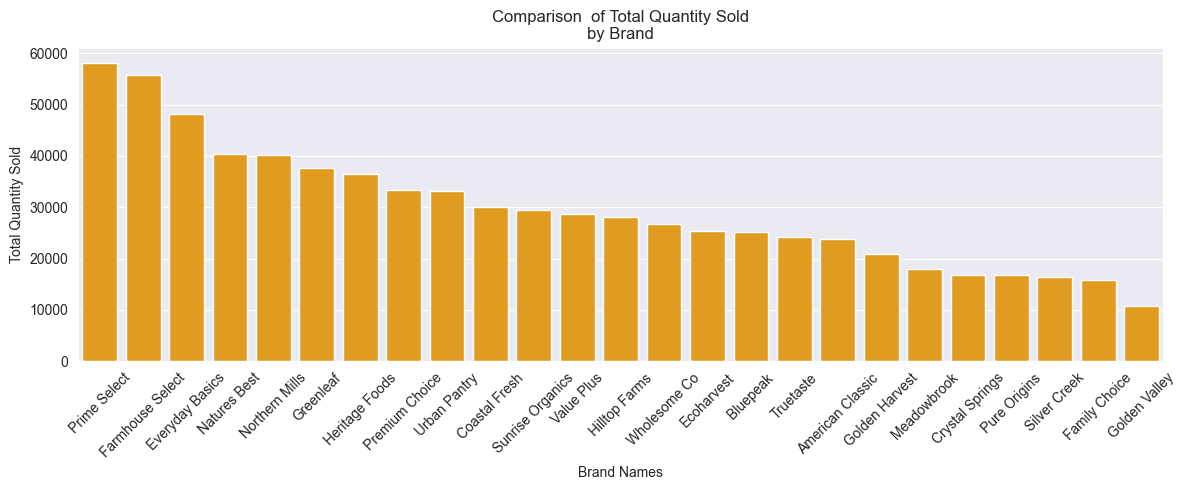

In [138]:
plt.figure(figsize= (12,5))
sns.barplot(x = brand_qty.index, y = brand_qty.values, order = brand_qty.index, color = "orange")
plt.tick_params(axis= "x", rotation = 45)
plt.xlabel("Brand Names")
plt.ylabel("Total Quantity Sold")
plt.title("Comparison  of Total Quantity Sold\nby Brand")
plt.tight_layout()
plt.savefig("Comparison  of Total Quantity Sold by Brand")

From the above graph, we can see that **Prime Select** has the highest total quantity sold, followed by **Farmhouse Select and Everyday Basics**. Prime Select sold approximately **58K units**, while Farmhouse Select and Everyday Basics sold around **56K and 48K units**, respectively.
The demand is moderately concentrated among the top-performing brands. However, demand is not dominated by only a few brands, as several brands in the middle of the ranking also contribute substantial sales volumes.

**Key business insight:** FreshMart should prioritize inventory availability for the leading brands, particularly Prime Select and Farmhouse Select, while continuing to monitor the middle-performing brands for opportunities to increase their contribution.

**3. How does sales performance differ across store types and individual stores, and which stores consistently outperform or underperform?**

In [26]:
sto = pd.read_csv(r"C:\Users\Ranu Gupta\OneDrive\Desktop\Project 1- Sales Analytics'\cleaned dataset\cleaned Stores.csv")

In [27]:
sto.head(2)

,store_id,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,last_remodel_date,total_sqft,grocery_sqft
0,1,80,Mid-Size Grocery,Valuegrocer #001 - Edmonton,2885 Hill St,Edmonton,AB,Canada,4.345477e+09,1993-02-18,NaN,20931,12981.0
1,2,17,Gourmet Supermarket,Groceryworld #002 - Raleigh,8157 Maple Dr,Raleigh,NC,USA,3.334671e+09,1986-09-01,1996-11-14,26060,19526.0


In [28]:
sto.describe().round(2)

,store_id,region_id,store_phone,total_sqft,grocery_sqft
count,24.00,24.00,2.300000e+01,24.00,24.00
mean,12.50,40.12,5.924721e+09,30895.88,21386.83
std,7.07,26.20,2.548218e+09,15631.68,10416.41
min,1.00,4.00,2.059722e+09,7264.00,10044.00
25%,6.75,18.50,3.743248e+09,20699.50,12659.50
50%,12.50,33.00,5.345855e+09,28153.50,19526.00
75%,18.25,58.50,8.199651e+09,34894.50,23261.25
max,24.00,100.00,9.744108e+09,60654.00,42591.00


In [29]:
sto.isna().sum()

store_id                 0
region_id                0
store_type               0
store_name               0
store_street_address     0
store_city               0
store_state              0
store_country            0
store_phone              1
first_opened_date        0
last_remodel_date       12
total_sqft               0
grocery_sqft             0
dtype: int64

In [30]:
sto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   store_id              24 non-null     int64  
 1   region_id             24 non-null     int64  
 2   store_type            24 non-null     object 
 3   store_name            24 non-null     object 
 4   store_street_address  24 non-null     object 
 5   store_city            24 non-null     object 
 6   store_state           24 non-null     object 
 7   store_country         24 non-null     object 
 8   store_phone           23 non-null     float64
 9   first_opened_date     24 non-null     object 
 10  last_remodel_date     12 non-null     object 
 11  total_sqft            24 non-null     int64  
 12  grocery_sqft          24 non-null     float64
dtypes: float64(2), int64(3), object(8)
memory usage: 2.6+ KB


In [31]:
for col in ["store_id", "region_id"]:
    sto[col] = sto[col].astype(str)

In [32]:
sto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   store_id              24 non-null     object 
 1   region_id             24 non-null     object 
 2   store_type            24 non-null     object 
 3   store_name            24 non-null     object 
 4   store_street_address  24 non-null     object 
 5   store_city            24 non-null     object 
 6   store_state           24 non-null     object 
 7   store_country         24 non-null     object 
 8   store_phone           23 non-null     float64
 9   first_opened_date     24 non-null     object 
 10  last_remodel_date     12 non-null     object 
 11  total_sqft            24 non-null     int64  
 12  grocery_sqft          24 non-null     float64
dtypes: float64(2), int64(1), object(10)
memory usage: 2.6+ KB


In [33]:
# merging cleaned store and tr_clean(created earlier) tables:
sto_tran_merge = pd.merge(sto,tr_clean, on = "store_id")

In [34]:
sto_tran_merge.head(2)

,store_id,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,transaction_date,stock_date,product_id,customer_id,quantity,month,year
0,1,80,Mid-Size Grocery,Valuegrocer #001 - Edmonton,2885 Hill St,Edmonton,AB,Canada,4.345477e+09,1993-02-18,NaN,20931,12981.0,1997-08-19,1997-08-22,518,878,4.0,8.0,1997.0
1,1,80,Mid-Size Grocery,Valuegrocer #001 - Edmonton,2885 Hill St,Edmonton,AB,Canada,4.345477e+09,1993-02-18,NaN,20931,12981.0,1997-06-06,1997-05-29,1380,8886,3.0,6.0,1997.0


In [35]:
store_type_qty = sto_tran_merge.groupby("store_type")["quantity"].sum().sort_values(ascending= False)

In [36]:
store_type_qty

store_type
Deluxe Supermarket     298705.0
Supermarket            201876.0
Mid-Size Grocery       119491.0
Gourmet Supermarket    112466.0
Small Grocery            7501.0
Name: quantity, dtype: float64

In [37]:
store_name_qty = sto_tran_merge.groupby("store_name")["quantity"].sum().sort_values(ascending= True)

In [38]:
store_name_qty

store_name
Pantryplus #016 - Los Angeles         7501.0
Supersave #024 - Memphis             11246.0
Pantryplus #020 - Tampa              11998.0
Pantryplus #017 - Minneapolis        13662.0
Freshmart #022 - Boulder             14143.0
Supersave #021 - Reno                15188.0
Valuegrocer #019 - Sacramento        17223.0
Supersave #015 - Raleigh             17988.0
Freshmart #023 - Detroit             19633.0
Freshmart #006 - Long Beach          21638.0
Valuegrocer #001 - Edmonton          22839.0
Marketplace #013 - Albany            23560.0
Groceryworld #002 - Raleigh          28902.0
Foodmart #010 - Indianapolis         33570.0
Groceryworld #009 - Detroit          33891.0
Freshmart #007 - Colorado Springs    33921.0
Foodmart #012 - Orlando              35710.0
Supersave #008 - Omaha               35768.0
Supersave #004 - Pittsburgh          42953.0
Foodmart #018 - Vancouver            46032.0
Freshmart #005 - Atlanta             56340.0
Valuegrocer #003 - San Antonio       64552.0

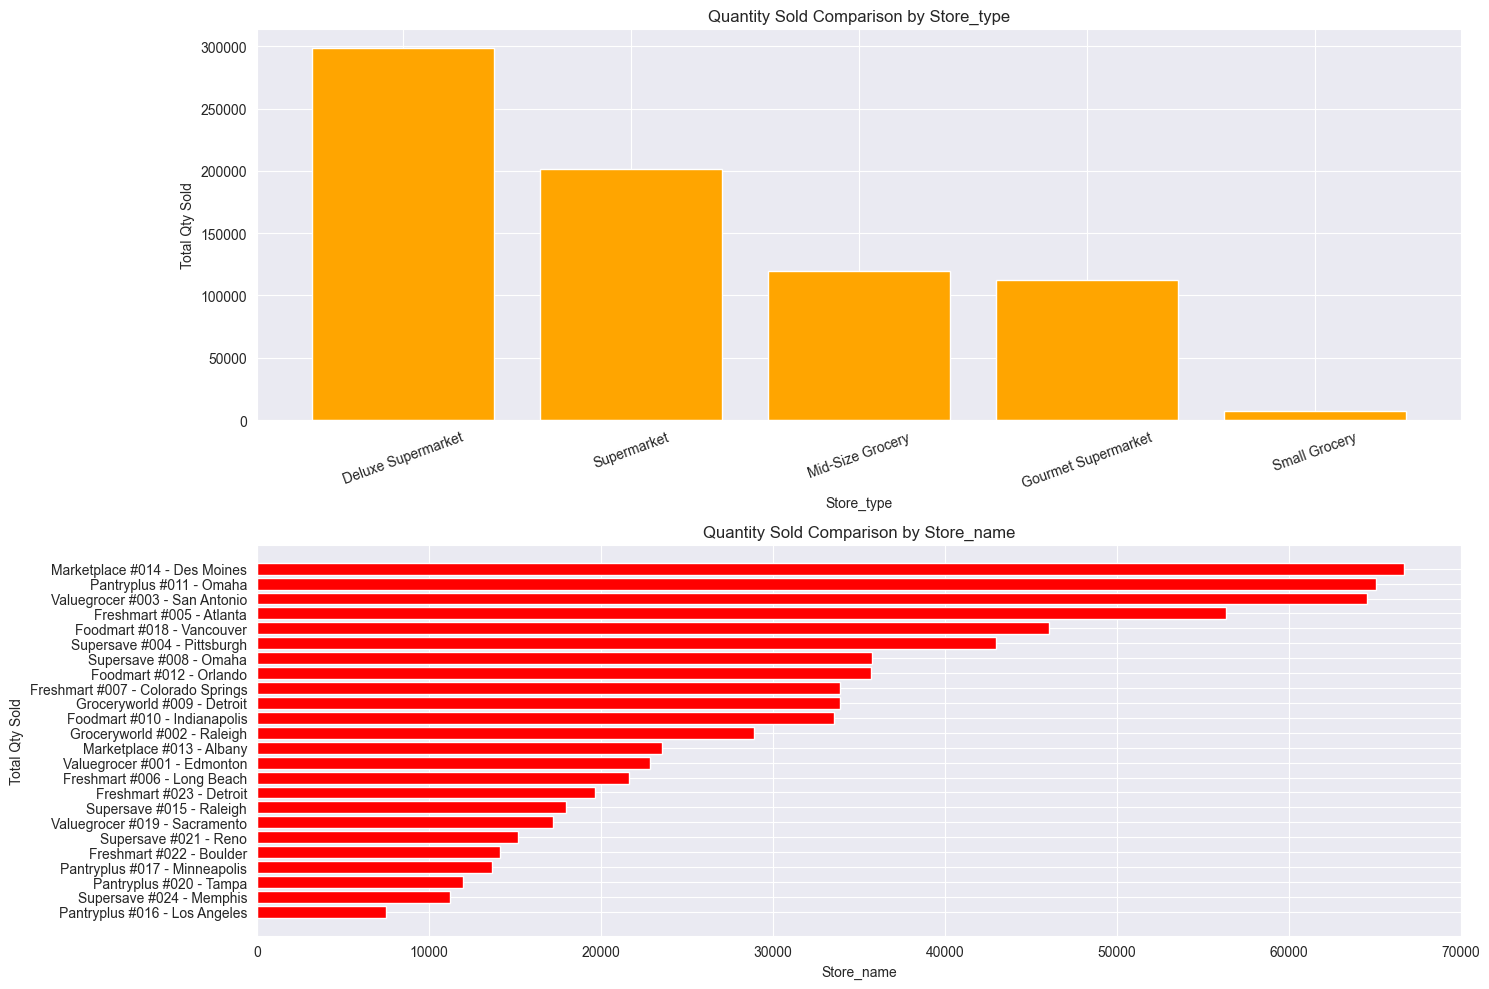

In [152]:
fig, ax = plt.subplots(2,1, figsize =(15,10))

#chart 1
ax[0].bar(store_type_qty.index, store_type_qty.values, color = "orange")
ax[0].tick_params(axis = "x", rotation = 20)
ax[0].set_xlabel("Store_type")
ax[0].set_ylabel("Total Qty Sold")
ax[0].set_title("Quantity Sold Comparison by Store_type")

#chart 2
ax[1].barh(store_name_qty.index, store_name_qty.values, color = "red")
ax[1].set_xlabel("Store_name")
ax[1].set_ylabel("Total Qty Sold")
ax[1].set_title("Quantity Sold Comparison by Store_name")


plt.tight_layout()
plt.savefig("Quantity Sold Comparison")

Sales performance across store types:
- **Deluxe Supermarkets** sold the highest total quantity, followed by Supermarkets.
- **Mid-Size Grocery** and Gourmet Supermarket recorded fairly similar total quantities sold.
- **Small Grocery stores** had the lowest total quantity sold among the store types.
Sales performance across individual stores:
- **Marketplace #014** - Des Moines recorded the highest quantity sold, followed by **Pantryplus #011** - Omaha and **Valuegrocer #003** - San Antonio.
- The top-performing stores account for a substantial share of total quantity sold, but sales are spread across multiple stores rather than being dominated by just one or two stores.
- Several stores in the middle of the ranking also contribute meaningful sales volumes.<br>

**Important Note:**
This analysis is based on quantity sold, not revenue. Therefore, a store with a higher quantity sold does not necessarily generate higher revenue, since revenue also depends on factors such as product prices and product mix.

In [40]:
month_store_type = sto_tran_merge.groupby(["month", "store_type"])["quantity"].sum().reset_index(name = "quantity")

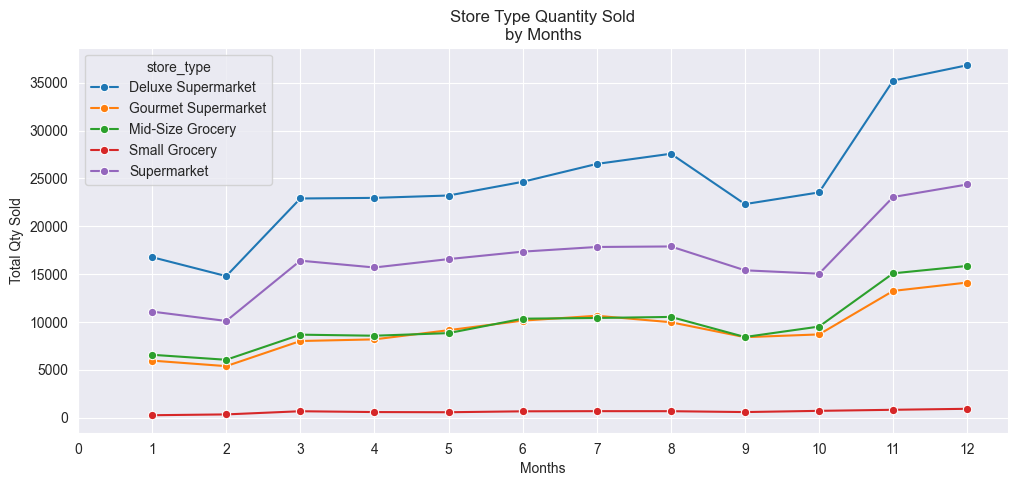

In [140]:
plt.figure(figsize= (12,5))
sns.lineplot(data = month_store_type, x = "month", y = "quantity", hue = "store_type",marker = "o",palette= "tab10")
plt.xticks(range(0,13))
plt.title("Store Type Quantity Sold\nby Months")
plt.xlabel("Months")
plt.ylabel("Total Qty Sold")
plt.savefig("Store Type Quantity Sold by Months")

**Deluxe Supermarket** — consistently the strongest performer. It has the highest quantity sold in every month.<br>
**Supermarket** — consistently second-best, staying well above the remaining store types throughout the year. <br>
**Mid-Size Grocery** — middle performer. It generally outperforms Gourmet Supermarket, especially toward the later months, but the two are quite close.<br>
**Gourmet Supermarket** — slightly underperforms Mid-Size Grocery for most months, although the gap is small.<br>
**Small Grocery** — consistently the weakest performer by a large margin, remaining far below all other store types throughout the year.

**4.) Which customer segments generate the most revenue, and how does revenue contribution differ across income, education, gender, and membership card categories?**

In [42]:
merge_pro_tr.head(5)

,product_id,product_brand,product_name,product_sku,product_retail_price,product_cost,product_weight,recyclable,low_fat,transaction_date,stock_date,customer_id,store_id,quantity,month,year
0,1,Ecoharvest,Ecoharvest Extra Crunchy Lotion,E-00001-X,10.53,4.52,1.07,No,No,1997-03-05,1997-02-23,2301,2,3.0,3.0,1997.0
1,1,Ecoharvest,Ecoharvest Extra Crunchy Lotion,E-00001-X,10.53,4.52,1.07,No,No,1997-01-31,1997-01-23,2371,4,2.0,1.0,1997.0
2,1,Ecoharvest,Ecoharvest Extra Crunchy Lotion,E-00001-X,10.53,4.52,1.07,No,No,1997-06-25,1997-06-24,7378,9,2.0,6.0,1997.0
3,1,Ecoharvest,Ecoharvest Extra Crunchy Lotion,E-00001-X,10.53,4.52,1.07,No,No,1997-05-20,1997-05-16,7608,8,2.0,5.0,1997.0
4,1,Ecoharvest,Ecoharvest Extra Crunchy Lotion,E-00001-X,10.53,4.52,1.07,No,No,1997-05-26,1997-05-21,2138,1,7.0,5.0,1997.0


In [43]:
qty_arr = np.array(merge_pro_tr["quantity"])

In [44]:
retail_price_arr = np.array(merge_pro_tr["product_retail_price"])

In [45]:
merge_pro_tr["order_value"] = qty_arr*retail_price_arr

In [46]:
merge_pro_tr.head(5)

,product_id,product_brand,product_name,product_sku,product_retail_price,product_cost,product_weight,recyclable,low_fat,transaction_date,stock_date,customer_id,store_id,quantity,month,year,order_value
0,1,Ecoharvest,Ecoharvest Extra Crunchy Lotion,E-00001-X,10.53,4.52,1.07,No,No,1997-03-05,1997-02-23,2301,2,3.0,3.0,1997.0,31.59
1,1,Ecoharvest,Ecoharvest Extra Crunchy Lotion,E-00001-X,10.53,4.52,1.07,No,No,1997-01-31,1997-01-23,2371,4,2.0,1.0,1997.0,21.06
2,1,Ecoharvest,Ecoharvest Extra Crunchy Lotion,E-00001-X,10.53,4.52,1.07,No,No,1997-06-25,1997-06-24,7378,9,2.0,6.0,1997.0,21.06
3,1,Ecoharvest,Ecoharvest Extra Crunchy Lotion,E-00001-X,10.53,4.52,1.07,No,No,1997-05-20,1997-05-16,7608,8,2.0,5.0,1997.0,21.06
4,1,Ecoharvest,Ecoharvest Extra Crunchy Lotion,E-00001-X,10.53,4.52,1.07,No,No,1997-05-26,1997-05-21,2138,1,7.0,5.0,1997.0,73.71


In [47]:
merge_pro_tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262996 entries, 0 to 262995
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   product_id            262996 non-null  object        
 1   product_brand         262996 non-null  object        
 2   product_name          262996 non-null  object        
 3   product_sku           262996 non-null  object        
 4   product_retail_price  262996 non-null  float64       
 5   product_cost          262996 non-null  float64       
 6   product_weight        262996 non-null  float64       
 7   recyclable            262996 non-null  object        
 8   low_fat               262996 non-null  object        
 9   transaction_date      261702 non-null  datetime64[ns]
 10  stock_date            260325 non-null  datetime64[ns]
 11  customer_id           249847 non-null  string        
 12  store_id              262996 non-null  object        
 13 

In [48]:
merge_pro_tr.isna().sum()

product_id                  0
product_brand               0
product_name                0
product_sku                 0
product_retail_price        0
product_cost                0
product_weight              0
recyclable                  0
low_fat                     0
transaction_date         1294
stock_date               2671
customer_id             13149
store_id                    0
quantity                    0
month                    1294
year                     1294
order_value                 0
dtype: int64

In [49]:
merge_pro_tr.describe().round(2)

,product_retail_price,product_cost,product_weight,transaction_date,stock_date,quantity,month,year,order_value
count,262996.00,262996.00,262996.00,261702,260325,262996.00,261702.00,261702.00,262996.00
mean,5.62,2.98,1.58,1998-03-27 13:12:33.311782144,1998-03-22 04:25:24.549697280,2.81,7.22,1997.68,15.80
min,0.51,0.23,0.20,1997-01-01 00:00:00,1996-12-22 00:00:00,0.00,1.00,1997.00,0.00
25%,3.18,1.65,0.94,1997-11-06 00:00:00,1997-10-31 00:00:00,2.00,4.00,1997.00,6.52
50%,4.71,2.48,1.36,1998-05-02 00:00:00,1998-04-26 00:00:00,2.00,7.00,1998.00,11.22
75%,8.13,4.04,2.18,1998-09-12 00:00:00,1998-09-06 00:00:00,3.00,10.00,1998.00,20.06
max,15.86,14.07,3.97,1998-12-31 00:00:00,1999-01-05 00:00:00,98.00,12.00,1998.00,872.90
std,3.15,1.77,0.85,NaN,NaN,2.89,3.41,0.47,20.44


In [50]:
cust = pd.read_csv(r"C:\Users\Ranu Gupta\OneDrive\Desktop\Project 1- Sales Analytics'\cleaned dataset\cleaned Customers.csv")

In [51]:
cust.head(2)

,customer_id,customer_acct_num,first_name,last_name,customer_address,customer_city,customer_state_province,customer_postal_code,customer_country,birthdate,marital_status,yearly_income,gender,total_children,num_children_at_home,education,acct_open_date,member_card,occupation,homeowner
0,1,ACC0000001,Robert,Wright,6598 Cedar Ln,Newark,NJ,50394,USA,NaN,Single,$130K - $150K,Male,1,1,High School,1991-11-14,Normal,Management,Yes
1,2,ACC0000002,Daniel,Lopez,1652 1st St,Tucson,AZ,31676,USA,1959-06-10,Married,NaN,Male,2,2,High School,1998-10-23,Bronze,Professional,Yes


In [52]:
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10281 entries, 0 to 10280
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   customer_id              10281 non-null  int64 
 1   customer_acct_num        10281 non-null  object
 2   first_name               10281 non-null  object
 3   last_name                10281 non-null  object
 4   customer_address         10281 non-null  object
 5   customer_city            10281 non-null  object
 6   customer_state_province  10281 non-null  object
 7   customer_postal_code     9670 non-null   object
 8   customer_country         10281 non-null  object
 9   birthdate                9766 non-null   object
 10  marital_status           10097 non-null  object
 11  yearly_income            9237 non-null   object
 12  gender                   10281 non-null  object
 13  total_children           10281 non-null  int64 
 14  num_children_at_home     10281 non-nul

In [53]:
cust["customer_id"] = cust["customer_id"].astype(str)

In [54]:
cust["birthdate"] = smart_parse_dates(cust["birthdate"])

In [55]:
cust["acct_open_date"] = smart_parse_dates(cust["acct_open_date"])

In [56]:
order = [
    '$10K - $30K',
    '$30K - $50K',
    '$50K - $70K',
    '$70K - $90K',
    '$90K - $110K',
    '$110K - $130K',
    '$130K - $150K',
    '$150K+'
]

cust['yearly_income'] = pd.Categorical(
    cust['yearly_income'],
    categories=order,
    ordered=True
)

In [57]:
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10281 entries, 0 to 10280
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              10281 non-null  object        
 1   customer_acct_num        10281 non-null  object        
 2   first_name               10281 non-null  object        
 3   last_name                10281 non-null  object        
 4   customer_address         10281 non-null  object        
 5   customer_city            10281 non-null  object        
 6   customer_state_province  10281 non-null  object        
 7   customer_postal_code     9670 non-null   object        
 8   customer_country         10281 non-null  object        
 9   birthdate                9766 non-null   datetime64[ns]
 10  marital_status           10097 non-null  object        
 11  yearly_income            9237 non-null   category      
 12  gender                   10281 n

In [58]:
#merging the customer table also to answer this question:
cust_pro_tr = pd.merge(merge_pro_tr, cust, on = "customer_id")

In [59]:
cust_pro_tr.head(2)

,product_id,product_brand,product_name,product_sku,product_retail_price,product_cost,product_weight,recyclable,low_fat,transaction_date,...,marital_status,yearly_income,gender,total_children,num_children_at_home,education,acct_open_date,member_card,occupation,homeowner
0,1,Ecoharvest,Ecoharvest Extra Crunchy Lotion,E-00001-X,10.53,4.52,1.07,No,No,1997-03-05,...,Single,$70K - $90K,Female,0,0,High School,1995-12-21,Gold,Skilled Manual,No
1,1,Ecoharvest,Ecoharvest Extra Crunchy Lotion,E-00001-X,10.53,4.52,1.07,No,No,1997-01-31,...,Single,$50K - $70K,Female,0,0,Some College,1990-11-05,Gold,Professional,Yes


In [60]:
gender_revenue = cust_pro_tr.groupby("gender")["order_value"].sum().sort_values(ascending= False).reset_index(name = "Revenue")

In [61]:
gender_revenue

,gender,Revenue
0,Female,1996143.40
1,Male,1945051.91


In [62]:
education_revenue = cust_pro_tr.groupby("education")["order_value"].sum().sort_values(ascending= False).reset_index(name = "Revenue")

In [63]:
education_revenue

,education,Revenue
0,High School,1187959.22
1,Bachelor'S Degree,1002367.13
2,Some College,989620.43
3,Graduate Degree,477432.33
4,Partial High School,283816.20


In [64]:
income_revenue = cust_pro_tr.groupby("yearly_income")["order_value"].sum().sort_values(ascending = False).reset_index(name = "Revenue")

C:\Users\Ranu Gupta\AppData\Local\Temp\ipykernel_9124\3306999634.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_revenue = cust_pro_tr.groupby("yearly_income")["order_value"].sum().sort_values(ascending = False).reset_index(name = "Revenue")


In [65]:
income_revenue

,yearly_income,Revenue
0,$50K - $70K,1012723.77
1,$30K - $50K,840782.49
2,$70K - $90K,523269.46
3,$10K - $30K,444451.05
4,$90K - $110K,342546.91
5,$110K - $130K,166304.90
6,$150K+,114083.17
7,$130K - $150K,101368.62


In [66]:
member_revenue = cust_pro_tr.groupby("member_card")["order_value"].sum().sort_values(ascending = False).reset_index(name= "Revenue")

In [67]:
member_revenue

,member_card,Revenue
0,Bronze,1314956.39
1,Normal,1157162.21
2,Silver,1079057.31
3,Gold,390019.40


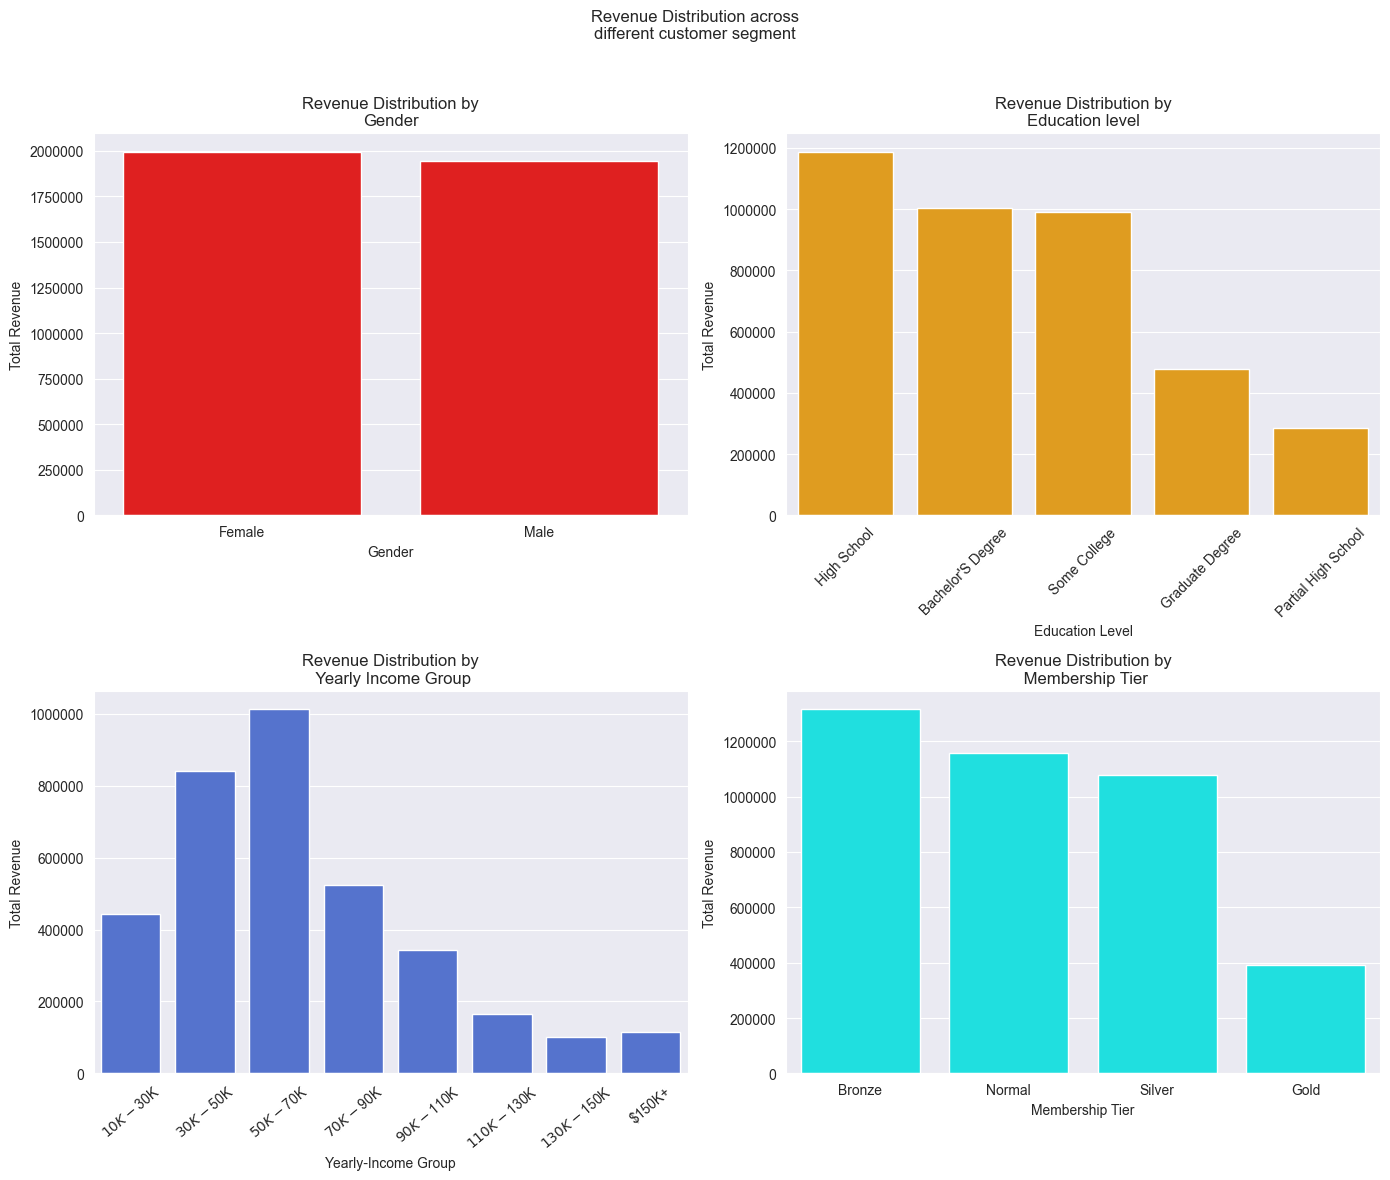

In [141]:
fig, ax = plt.subplots(2,2, figsize = (14,12))

#chart 1:
sns.barplot(data = gender_revenue, x = "gender" , y = "Revenue", ax = ax[0,0], color = "red")
ax[0, 0].ticklabel_format(style='plain', axis='y')
ax[0,0].set_xlabel("Gender")
ax[0,0].set_ylabel("Total Revenue")
ax[0,0].set_title("Revenue Distribution by\nGender")

#chart 2:
sns.barplot(data = education_revenue, x = "education", y = "Revenue", ax =  ax[0,1], color = "orange")
ax[0,1].tick_params(axis = "x", rotation = 45)
ax[0,1].ticklabel_format(style = "plain", axis = "y")
ax[0,1].set_xlabel("Education Level")
ax[0,1].set_ylabel("Total Revenue")
ax[0,1].set_title("Revenue Distribution by\nEducation level")

#chart 3:
sns.barplot(data = income_revenue, x= "yearly_income", y = "Revenue", ax = ax[1,0], color = "royalblue")
ax[1,0].ticklabel_format(style = "plain", axis = "y")
ax[1,0].tick_params(axis = "x", rotation = 40)
ax[1,0].set_xlabel("Yearly-Income Group")
ax[1,0].set_ylabel("Total Revenue")
ax[1,0].set_title("Revenue Distribution by\n Yearly Income Group")

#chart 4:
sns.barplot(data = member_revenue, x = "member_card", y = "Revenue", ax = ax[1,1], color = "cyan")
ax[1,1].ticklabel_format(style = "plain", axis = "y")
ax[1,1].set_xlabel("Membership Tier")
ax[1,1].set_ylabel("Total Revenue")
ax[1,1].set_title("Revenue Distribution by\n Membership Tier")


fig.suptitle("Revenue Distribution across\ndifferent customer segment")
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig("Revenue Distribution Dashboard")


**Customer Segment Revenue Analysis**
- **Gender**: Female and male customers have generated approximately similar revenue, with female customers contributing slightly more than male customers. <br>
- **Education**: Customers with a High School education level generated the highest revenue, followed by Bachelor's Degree and Some College customers. Partial High School customers generated the lowest revenue. <br>
- **Income**: The 50k–70k income group generated the highest revenue, followed by the 30k–50k group. Customers earning 150k+ generated the lowest revenue among the income groups.
- **Membership**: Bronze members generated the highest revenue, followed by Normal and Silver members. Gold members generated the lowest revenue. <br>

**Important consideration:** These charts show the total revenue generated by each segment, but they do not account for the number of customers within each segment. Therefore, a segment generating less total revenue may simply have fewer customers rather than lower customer-level spending.<br>

**Business insight:** The next step would be to compare customer count and revenue per customer across these segments. For segments with lower revenue, such as **Partial High School** and **Graduate Degree** customers, we can determine whether the gap is primarily due to a smaller customer base or lower spending. If customer counts are comparable, we can then investigate their product/category purchasing patterns to understand the differences in their purchasing behavior and identify opportunities to better serve these customer segments.

**5.) Do larger stores actually generate higher transaction volumes, or is store size a weak predictor of operational performance?**

In [69]:
sto_tran_merge.head(2)


,store_id,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,transaction_date,stock_date,product_id,customer_id,quantity,month,year
0,1,80,Mid-Size Grocery,Valuegrocer #001 - Edmonton,2885 Hill St,Edmonton,AB,Canada,4.345477e+09,1993-02-18,NaN,20931,12981.0,1997-08-19,1997-08-22,518,878,4.0,8.0,1997.0
1,1,80,Mid-Size Grocery,Valuegrocer #001 - Edmonton,2885 Hill St,Edmonton,AB,Canada,4.345477e+09,1993-02-18,NaN,20931,12981.0,1997-06-06,1997-05-29,1380,8886,3.0,6.0,1997.0


In [70]:
sto_tran_merge.shape

(263134, 20)

In [71]:
store_level = sto_tran_merge.groupby("store_id").agg(
    total_sqft=("total_sqft", "first"),
    grocery_sqft=("grocery_sqft", "first"),
    total_qty=("quantity", "sum"),
    txn_count=("quantity", "size")
).reset_index()

In [72]:
#Stores having physically impossible imputed grocery_sqft values exceeding its own total_sqft are excluded from this correlation
store_level_grocery = store_level[store_level["grocery_sqft"] < store_level["total_sqft"]]

In [73]:
np.corrcoef(store_level["total_sqft"], store_level["total_qty"]).round(4)

array([[1.    , 0.9695],
       [0.9695, 1.    ]])

In [74]:
np.corrcoef(store_level_grocery["grocery_sqft"], store_level_grocery["total_qty"]).round(4)

array([[1.    , 0.8165],
       [0.8165, 1.    ]])

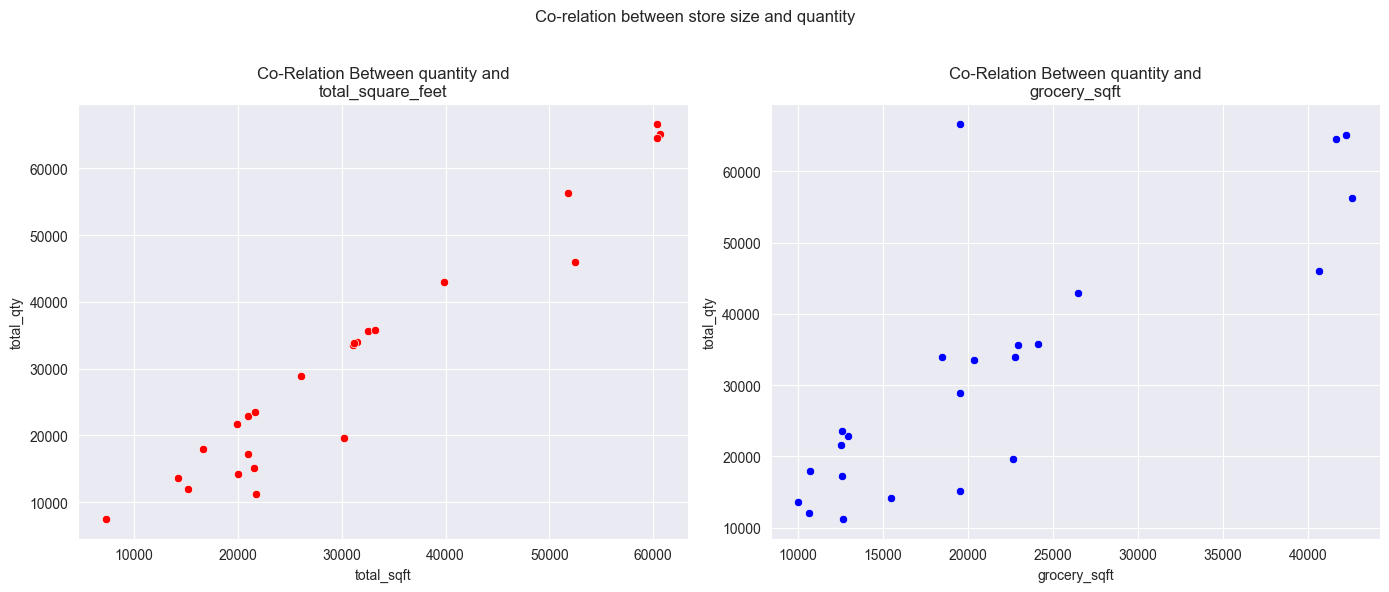

In [142]:
fig, ax = plt.subplots(1,2, figsize = (14,6))

#chart 1:
sns.scatterplot(data = store_level, x = "total_sqft", y = "total_qty", color = "red", ax = ax[0])
ax[0].set_title("Co-Relation Between quantity and\ntotal_square_feet")

#chart 2:
sns.scatterplot(data = store_level_grocery, x = "grocery_sqft", y = "total_qty", color = "blue", ax = ax[1])
ax[1].set_title("Co-Relation Between quantity and\ngrocery_sqft")

fig.suptitle("Co-relation between store size and quantity")
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig("Co-relation between store size and quantity")


##### Relationship Between Store Size and Transaction Volume

- The correlation between `total_sqft` and `quantity` is **0.9695**, indicating a very strong positive correlation between total store size and transaction quantity.

- Similarly, the correlation between `grocery_sqft` and `quantity` is **0.8165**, indicating a strong positive correlation between grocery store area and transaction quantity.

- The scatter plots show a clear **upward trend**, with larger stores generally associated with higher transaction quantities.

- Overall, the results suggest that **store size is a strong predictor of transaction volume**. Stores with larger total and grocery floor areas tend to generate higher transaction quantities.

- The relationship is particularly strong for `total_sqft`, with a correlation of approximately **0.97**, suggesting that total store size is more strongly associated with transaction volume than grocery area.

**6.) Are there particular regions or district where customer purchasing patterns differ substantially from the company-wide pattern?**

In [76]:
sto_tran_merge.head(2)

,store_id,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,transaction_date,stock_date,product_id,customer_id,quantity,month,year
0,1,80,Mid-Size Grocery,Valuegrocer #001 - Edmonton,2885 Hill St,Edmonton,AB,Canada,4.345477e+09,1993-02-18,NaN,20931,12981.0,1997-08-19,1997-08-22,518,878,4.0,8.0,1997.0
1,1,80,Mid-Size Grocery,Valuegrocer #001 - Edmonton,2885 Hill St,Edmonton,AB,Canada,4.345477e+09,1993-02-18,NaN,20931,12981.0,1997-06-06,1997-05-29,1380,8886,3.0,6.0,1997.0


In [77]:
sto_tran_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263134 entries, 0 to 263133
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   store_id              263134 non-null  object        
 1   region_id             263134 non-null  object        
 2   store_type            263134 non-null  object        
 3   store_name            263134 non-null  object        
 4   store_street_address  263134 non-null  object        
 5   store_city            263134 non-null  object        
 6   store_state           263134 non-null  object        
 7   store_country         263134 non-null  object        
 8   store_phone           250413 non-null  float64       
 9   first_opened_date     263134 non-null  object        
 10  last_remodel_date     126524 non-null  object        
 11  total_sqft            263134 non-null  int64         
 12  grocery_sqft          263134 non-null  float64       
 13 

In [78]:
reg =  pd.read_csv(r"C:\Users\Ranu Gupta\OneDrive\Desktop\Project 1- Sales Analytics'\cleaned dataset\cleaned Regions.csv")

In [79]:
reg.head(2)

,region_id,sales_district,sales_region
0,1,New York Ny,Northeast
1,2,Boston Ma,Northeast


In [80]:
reg.isna().sum()

region_id         0
sales_district    0
sales_region      0
dtype: int64

In [81]:
reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   region_id       109 non-null    int64 
 1   sales_district  109 non-null    object
 2   sales_region    109 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.7+ KB


In [82]:
reg["region_id"] = reg["region_id"].astype(str)

In [83]:
reg["sales_region"].unique()

array(['Northeast', 'South East', 'Southeast', 'Midwest', 'Mid West',
       'Southwest', 'South West', 'West', 'Pacific', 'Mountain', 'Canada',
       'Mexico'], dtype=object)

In [84]:
#missed the formatting region names during the cleaning phase:
def normalize_region(t):
    t = t.strip().lower().replace('-', ' ')
    if 'mid' in t and 'west' in t: return 'Midwest'
    if 'south' in t and 'east' in t: return 'Southeast'
    if 'south' in t and 'west' in t: return 'Southwest'
    if 'mountain' in t: return 'Mountain'
    return t.title()

reg["sales_region"] = reg["sales_region"].apply(normalize_region)

In [85]:
reg["sales_region"].unique()

array(['Northeast', 'Southeast', 'Midwest', 'Southwest', 'West',
       'Pacific', 'Mountain', 'Canada', 'Mexico'], dtype=object)

In [86]:
reg_merge_tran = pd.merge(sto_tran_merge, reg, on = "region_id")

In [87]:
reg_merge_tran.head(2)

,store_id,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,...,grocery_sqft,transaction_date,stock_date,product_id,customer_id,quantity,month,year,sales_district,sales_region
0,1,80,Mid-Size Grocery,Valuegrocer #001 - Edmonton,2885 Hill St,Edmonton,AB,Canada,4.345477e+09,1993-02-18,...,12981.0,1997-08-19,1997-08-22,518,878,4.0,8.0,1997.0,Edmonton Ab,Canada
1,1,80,Mid-Size Grocery,Valuegrocer #001 - Edmonton,2885 Hill St,Edmonton,AB,Canada,4.345477e+09,1993-02-18,...,12981.0,1997-06-06,1997-05-29,1380,8886,3.0,6.0,1997.0,Edmonton Ab,Canada


In [88]:
district_qty = reg_merge_tran.groupby("sales_district")["quantity"].sum().sort_values(ascending = True).reset_index(name = "Total Qty")

In [89]:
region_qty = reg_merge_tran.groupby("sales_region")["quantity"].sum().sort_values(ascending = False).reset_index(name = "Total Qty")

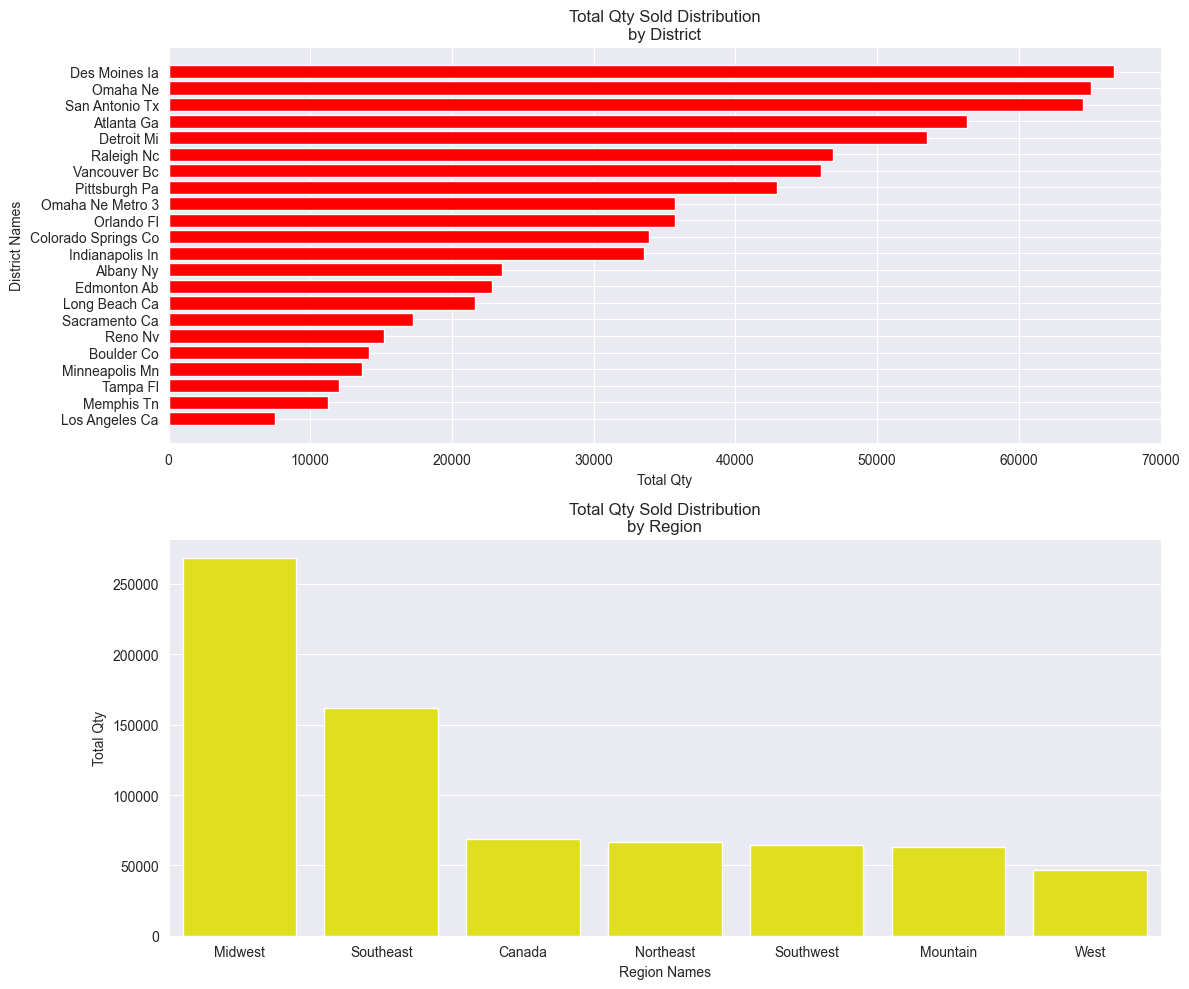

In [143]:
fig, ax = plt.subplots(2,1, figsize = (12,10))

# chart 1:
ax[0].barh(district_qty["sales_district"] ,district_qty["Total Qty"], color = "red")
ax[0].set_xlabel("Total Qty")
ax[0].set_ylabel("District Names")
ax[0].set_title("Total Qty Sold Distribution\nby District")

# chart 2:
sns.barplot(data = region_qty, x = "sales_region" , y = "Total Qty", ax = ax[1], color = "yellow")
ax[1].set_xlabel("Region Names")
ax[1].set_ylabel("Total Qty")
ax[1].set_title("Total Qty Sold Distribution\nby Region")

plt.tight_layout()
plt.savefig("Total Qty Sold Distribution")

**Regional analysis:**

The **Midwest region** has the highest quantity sold by a substantial margin, followed by the **Southeast region**. However, there is a significant gap between the two, with the Midwest contributing considerably more quantity. Most of the remaining regions have relatively similar sales volumes, while the **West region records slightly lower sales** compared with these regions.

**District analysis:**

At the district level, **Des Moines, IA** has the highest quantity sold, followed by **Omaha, NE** and **San Antonio, TX**. These three districts are the top contributors to overall sales volume, although the remaining districts also make meaningful contributions to total quantity sold.

For **further analysis**, I will investigate whether the high demand in the Midwest region is driven by a few particular product brands or is evenly distributed across the different brands.

In [91]:
reg_merge_tran.head(2)

,store_id,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,...,grocery_sqft,transaction_date,stock_date,product_id,customer_id,quantity,month,year,sales_district,sales_region
0,1,80,Mid-Size Grocery,Valuegrocer #001 - Edmonton,2885 Hill St,Edmonton,AB,Canada,4.345477e+09,1993-02-18,...,12981.0,1997-08-19,1997-08-22,518,878,4.0,8.0,1997.0,Edmonton Ab,Canada
1,1,80,Mid-Size Grocery,Valuegrocer #001 - Edmonton,2885 Hill St,Edmonton,AB,Canada,4.345477e+09,1993-02-18,...,12981.0,1997-06-06,1997-05-29,1380,8886,3.0,6.0,1997.0,Edmonton Ab,Canada


In [92]:
midwest_data = reg_merge_tran[reg_merge_tran["sales_region"] == "Midwest"]

In [93]:
midwest_data["sales_region"].value_counts()

sales_region
Midwest    95486
Name: count, dtype: int64

In [94]:
pro_midwest = pd.merge(midwest_data, pro, on = "product_id")

In [95]:
brand_mid_qty = pro_midwest.groupby("product_brand")["quantity"].sum().sort_values(ascending = True).reset_index(name = "Total_Qty")

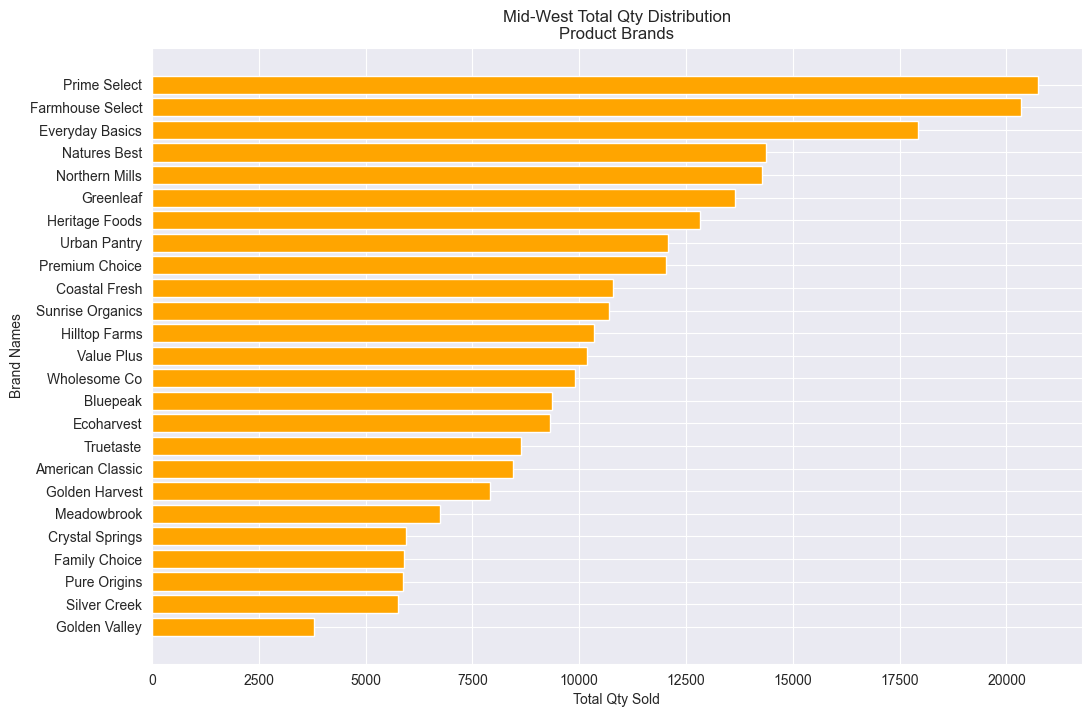

In [144]:
figure(figsize= (12,8))
plt.barh(brand_mid_qty["product_brand"], brand_mid_qty["Total_Qty"], color = "orange")
plt.title("Mid-West Total Qty Distribution\nProduct Brands")
plt.xlabel("Total Qty Sold")
plt.ylabel("Brand Names")
plt.savefig("Mid-West Total Qty Distribution")

**Further analysis of the Midwest region:**

The demand in the **Midwest region appears to be broadly distributed across product brands**, rather than being driven by only a small number of brands. **Prime Select** and **Farmhouse Select** have the highest quantities sold, followed by **Everyday Basics** and **Natures Best**. However, most of the other brands also contribute a meaningful volume, with a gradual decline in quantity across the brands.

This suggests that the high demand in the Midwest is **not heavily dependent on a few specific brands** and is relatively well distributed across the product portfolio.

**7.) Which products and stores have the highest return activity relative to their transaction volume.**

In [97]:
ret = pd.read_csv(r"C:\Users\Ranu Gupta\OneDrive\Desktop\Project 1- Sales Analytics'\cleaned dataset\cleaned Returns.csv")

In [98]:
ret.head(2)

,return_date,product_id,store_id,quantity
0,1998-08-27,206,4,3.0
1,1998-08-04,1224,6,3.0


In [99]:
ret.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6881 entries, 0 to 6880
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   return_date  6808 non-null   object 
 1   product_id   6881 non-null   int64  
 2   store_id     6881 non-null   int64  
 3   quantity     6881 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 215.2+ KB


In [100]:
ret["return_date"] = smart_parse_dates(ret["return_date"])

In [101]:
for col in ["product_id", "store_id"]:
    ret[col] = ret[col].astype(str)

In [102]:
ret.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6881 entries, 0 to 6880
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   return_date  6808 non-null   datetime64[ns]
 1   product_id   6881 non-null   object        
 2   store_id     6881 non-null   object        
 3   quantity     6881 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 215.2+ KB


In [103]:
ret.describe().round(2)

,return_date,quantity
count,6808,6881.00
mean,1998-04-16 18:45:53.936545408,3.05
min,1997-01-04 00:00:00,1.00
25%,1997-11-21 00:00:00,2.00
50%,1998-05-19 00:00:00,3.00
75%,1998-10-05 00:00:00,4.00
max,1999-02-11 00:00:00,5.00
std,NaN,1.42


In [104]:
return_by_product = ret.groupby("product_id")["quantity"].sum().reset_index(name = "returned_qty")
return_by_product

,product_id,returned_qty
0,1,7.0
1,1000,2.0
2,1001,47.0
3,1005,3.0
4,1006,5.0
...,...,...
1096,995,10.0
1097,996,41.0
1098,997,15.0
1099,998,20.0


In [105]:
tr_clean.head(2)

,transaction_date,stock_date,product_id,customer_id,store_id,quantity,month,year
0,1997-07-30,1997-07-29,667,1188,4,3.0,7.0,1997.0
1,1997-08-19,1997-08-22,518,878,1,4.0,8.0,1997.0


In [106]:
sold_by_product = tr_clean.groupby("product_id")["quantity"].sum().reset_index(name = "sold_qty")
sold_by_product

,product_id,sold_qty
0,1,52.0
1,10,14.0
2,100,323.0
3,1000,219.0
4,1001,1646.0
...,...,...
1603,995,223.0
1604,996,1322.0
1605,997,499.0
1606,998,477.0


In [107]:
return_prod = pd.merge(sold_by_product, return_by_product, on = "product_id", how = "left")

In [108]:
return_prod

,product_id,sold_qty,returned_qty
0,1,52.0,7.0
1,10,14.0,NaN
2,100,323.0,NaN
3,1000,219.0,2.0
4,1001,1646.0,47.0
...,...,...,...
1603,995,223.0,10.0
1604,996,1322.0,41.0
1605,997,499.0,15.0
1606,998,477.0,20.0


In [109]:
return_prod["returned_qty"] = return_prod["returned_qty"].fillna(0)

In [110]:
return_prod.isna().sum()

product_id      0
sold_qty        0
returned_qty    0
dtype: int64

In [111]:
return_prod["return_rate"] = (return_prod["returned_qty"]/return_prod["sold_qty"]*100).round(2)

In [112]:
#filtering lower sold qty rows so that the data is not misleading:
return_prod.describe().round(2)

,sold_qty,returned_qty,return_rate
count,1608.00,1608.00,1608.00
mean,460.65,13.07,3.03
std,1376.47,38.98,4.40
min,3.00,0.00,0.00
25%,60.00,0.00,0.00
50%,156.50,4.00,2.26
75%,378.25,12.00,4.00
max,36478.00,992.00,55.56


In [113]:
return_prod_clean = return_prod[return_prod["sold_qty"] >= 100]

In [114]:
return_prod_clean.shape

(1000, 4)

In [115]:
pro_return_clean = pd.merge(return_prod_clean, pro[["product_id", "product_brand", "product_name"]], on = "product_id")

In [116]:
top_10_prod = pro_return_clean.sort_values(by = "return_rate", ascending = False).head(10)

In [117]:
top_10_prod

,product_id,sold_qty,returned_qty,return_rate,product_brand,product_name
58,1091,205.0,29.0,14.15,Silver Creek,Silver Creek Gourmet Pork Chops
115,1167,159.0,21.0,13.21,Golden Harvest,Golden Harvest Jumbo Crab Legs
577,416,101.0,11.0,10.89,American Classic,American Classic Jumbo Bananas
32,1045,158.0,17.0,10.76,Ecoharvest,Ecoharvest Reduced Fat Sausage
650,527,167.0,17.0,10.18,Silver Creek,Silver Creek Mini Cod
546,37,119.0,12.0,10.08,Pure Origins,Pure Origins Value Pack Waffles
537,361,299.0,29.0,9.70,Urban Pantry,Urban Pantry Original Waffles
203,1289,127.0,12.0,9.45,Coastal Fresh,Coastal Fresh Low Sodium Cream
91,1134,130.0,12.0,9.23,Ecoharvest,Ecoharvest Lite Cod
380,1549,261.0,24.0,9.20,Natures Best,Natures Best Reduced Fat Lettuce


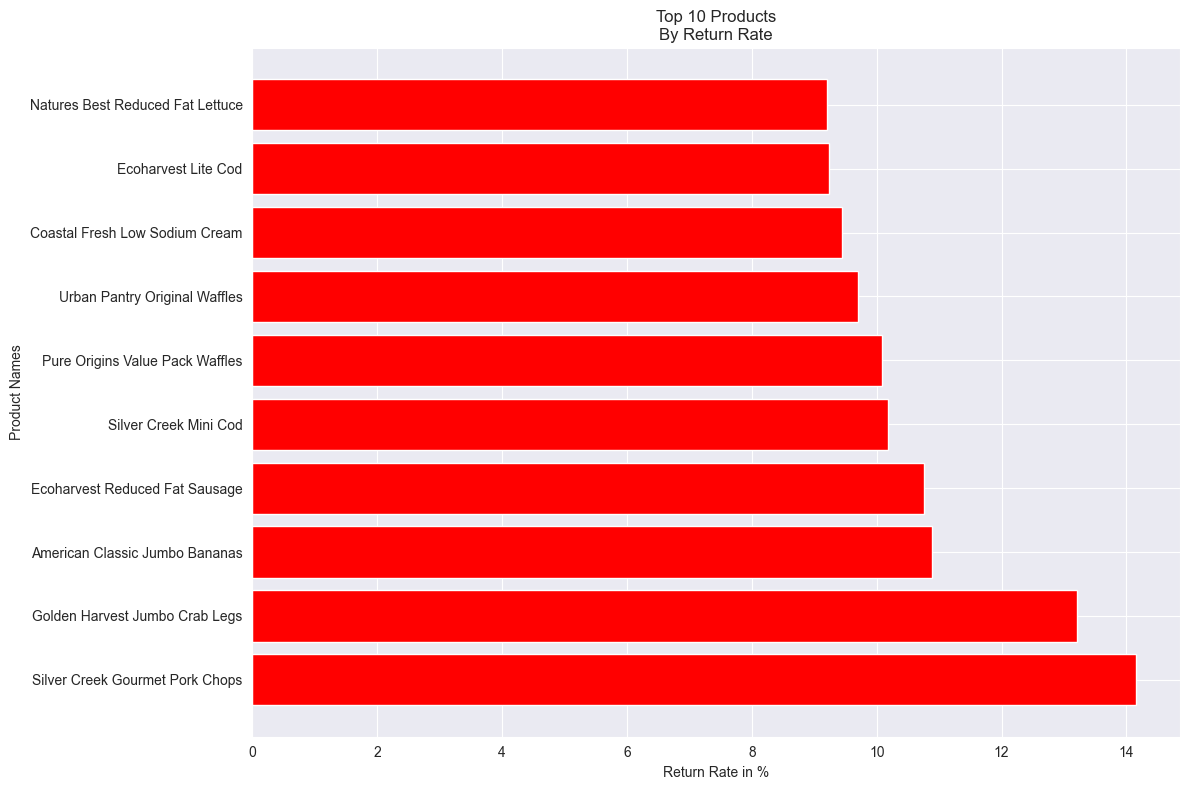

In [147]:
plt.figure(figsize = (12,8))
plt.barh(top_10_prod["product_name"], top_10_prod["return_rate"], color = "red")
plt.xlabel("Return Rate in %")
plt.ylabel("Product Names")
plt.title("Top 10 Products\nBy Return Rate")
plt.tight_layout()
plt.savefig("Top 10 Products By Return Rate")

**Product Return Rate Analysis:**

 **Silver Creek Gourmet Pork Chops** has the highest return rate at approximately **14.1%**, followed by **Golden Harvest Jumbo Crab Legs** at around **13.2%**. The return rates then drop noticeably, with **American Classic Jumbo Bananas** and **Ecoharvest Reduced Fat Sausage** at approximately **10.8%** and **10.7%**, respectively.

 The remaining products have return rates below **10%**, with **Natures Best Reduced Fat Lettuce** having the lowest return rate among the top 10 products at approximately **9.0%**.

 The significant gap between the top two products and the remaining products suggests that **Silver Creek Gourmet Pork Chops and Golden Harvest Jumbo Crab Legs warrant further investigation** to understand the reasons behind their comparatively high return rates.

In [119]:
ret.head(2)

,return_date,product_id,store_id,quantity
0,1998-08-27,206,4,3.0
1,1998-08-04,1224,6,3.0


In [120]:
return_by_store = ret.groupby("store_id")["quantity"].sum().reset_index(name = "returned_qty")

In [121]:
return_by_store.head()

,store_id,returned_qty
0,1,631.0
1,10,903.0
2,11,1904.0
3,12,902.0
4,13,629.0


In [122]:
tr_clean["store_id"].unique()

array(['4', '1', '5', '13', '7', '3', '10', '11', '14', '20', '8', '15',
       '9', '6', '19', '18', '17', '12', '2', '16', '22', '21', '26',
       '27', '25', '28', '23', '24'], dtype=object)

In [123]:
# Removed N transactions referencing a store_id not present in the Stores table (invalid/broken store reference)
tr_clean = tr_clean[tr_clean["store_id"].isin(sto["store_id"])]

In [124]:
tr_clean["store_id"].unique()

array(['4', '1', '5', '13', '7', '3', '10', '11', '14', '20', '8', '15',
       '9', '6', '19', '18', '17', '12', '2', '16', '22', '21', '23',
       '24'], dtype=object)

In [125]:
sold_by_store = tr_clean.groupby("store_id")["quantity"].sum().reset_index(name = "sold_qty")

In [126]:
store_return = pd.merge(sold_by_store, return_by_store, on = "store_id", how = "left")

In [127]:
store_return.isna().sum()

store_id        0
sold_qty        0
returned_qty    0
dtype: int64

In [128]:
store_return.describe().round(2)

,sold_qty,returned_qty
count,24.00,24.00
mean,30834.96,874.54
std,18035.05,524.31
min,7501.00,197.00
25%,16714.25,445.50
50%,26231.00,694.50
75%,37564.25,1086.75
max,66694.00,1906.00


In [129]:
store_return_clean = store_return[store_return["sold_qty"] >= 10000]

In [130]:
store_return_clean["return_rate"] = (store_return_clean["returned_qty"]/store_return_clean["sold_qty"]*100).round(2)

C:\Users\Ranu Gupta\AppData\Local\Temp\ipykernel_9124\2347403390.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  store_return_clean["return_rate"] = (store_return_clean["returned_qty"]/store_return_clean["sold_qty"]*100).round(2)


In [131]:
top_10_store = store_return_clean.sort_values(by = "return_rate", ascending = False).head(10)

In [132]:
top_10_store

,store_id,sold_qty,returned_qty,return_rate
6,15,17988.0,575.0,3.20
8,17,13662.0,418.0,3.06
14,22,14143.0,426.0,3.01
18,4,42953.0,1281.0,2.98
21,7,33921.0,995.0,2.93
2,11,65087.0,1904.0,2.93
9,18,46032.0,1342.0,2.92
19,5,56340.0,1635.0,2.90
5,14,66694.0,1906.0,2.86
22,8,35768.0,1022.0,2.86


In [133]:
top_10_store = pd.merge(top_10_store, sto[["store_id", "store_name"]], on = "store_id")

In [134]:
top_10_store

,store_id,sold_qty,returned_qty,return_rate,store_name
0,15,17988.0,575.0,3.20,Supersave #015 - Raleigh
1,17,13662.0,418.0,3.06,Pantryplus #017 - Minneapolis
2,22,14143.0,426.0,3.01,Freshmart #022 - Boulder
3,4,42953.0,1281.0,2.98,Supersave #004 - Pittsburgh
4,7,33921.0,995.0,2.93,Freshmart #007 - Colorado Springs
5,11,65087.0,1904.0,2.93,Pantryplus #011 - Omaha
6,18,46032.0,1342.0,2.92,Foodmart #018 - Vancouver
7,5,56340.0,1635.0,2.90,Freshmart #005 - Atlanta
8,14,66694.0,1906.0,2.86,Marketplace #014 - Des Moines
9,8,35768.0,1022.0,2.86,Supersave #008 - Omaha


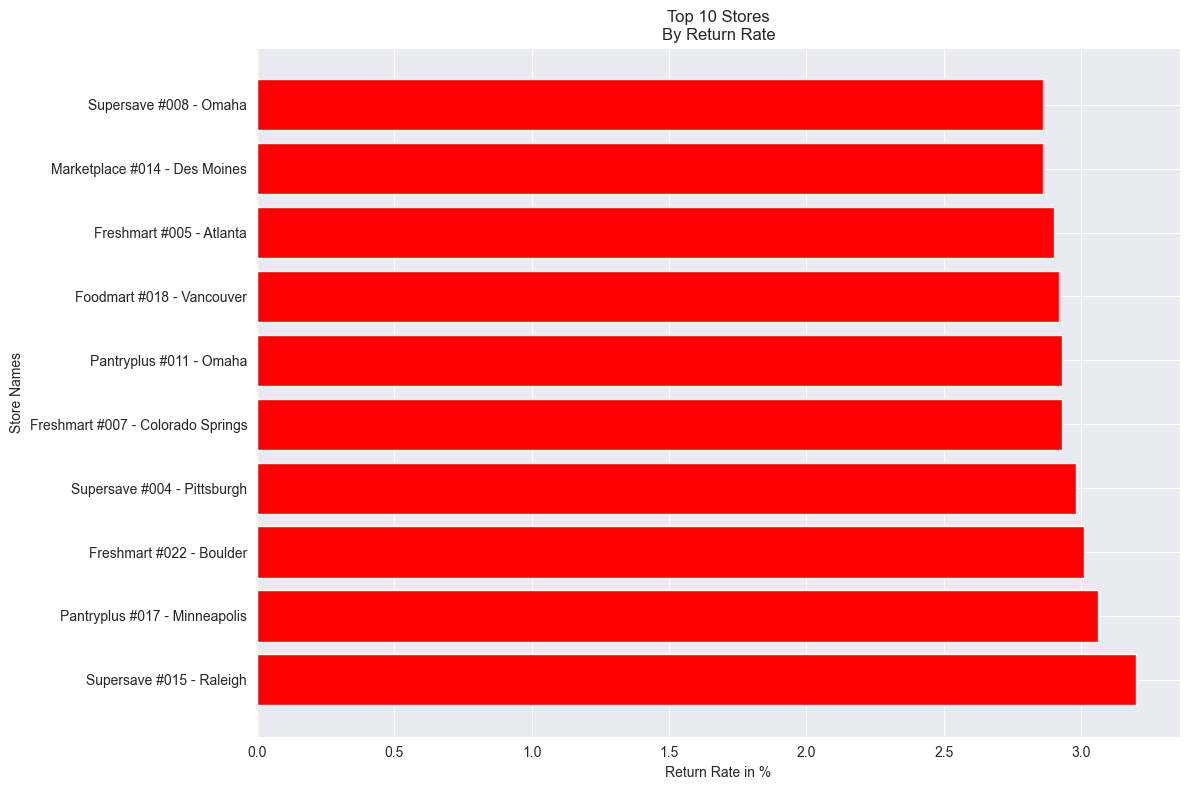

In [148]:
plt.figure(figsize = (12,8))
plt.barh(top_10_store["store_name"], top_10_store["return_rate"], color = "red")
plt.title("Top 10 Stores\nBy Return Rate")
plt.xlabel("Return Rate in %")
plt.ylabel("Store Names")
plt.tight_layout()
plt.savefig("Top 10 Stores By Return Rat")

**Store Return Rate Analysis:**

**Supersave #015 - Raleigh** has the highest return rate at approximately **3.2%**, followed by **Pantryplus #017 - Minneapolis** at around **3.1%** and **Freshmart #022 - Boulder** at approximately **3.0%**.

 The remaining stores in the top 10 have return rates between approximately **2.8% and 3.0%**. Overall, the return rates are relatively close, with **Raleigh and Minneapolis standing out slightly** from the other stores.

 These stores could be investigated further to understand whether their higher return rates are associated with **specific products, product categories, or customer purchasing patterns**.